<a href="https://colab.research.google.com/github/amridhanmahdi/traffic_flow_violation/blob/main/Car_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("guisahanes/traffic-violation-detection-dataset")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/guisahanes/traffic-violation-detection-dataset/versions/1


In [ ]:
!pip install ultralytics

from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
import random

DATA_YAML = Path(path) / "data.yaml"
IMAGES_VAL = Path(path) / "images" / "val"
SEED = 42
random.seed(SEED)

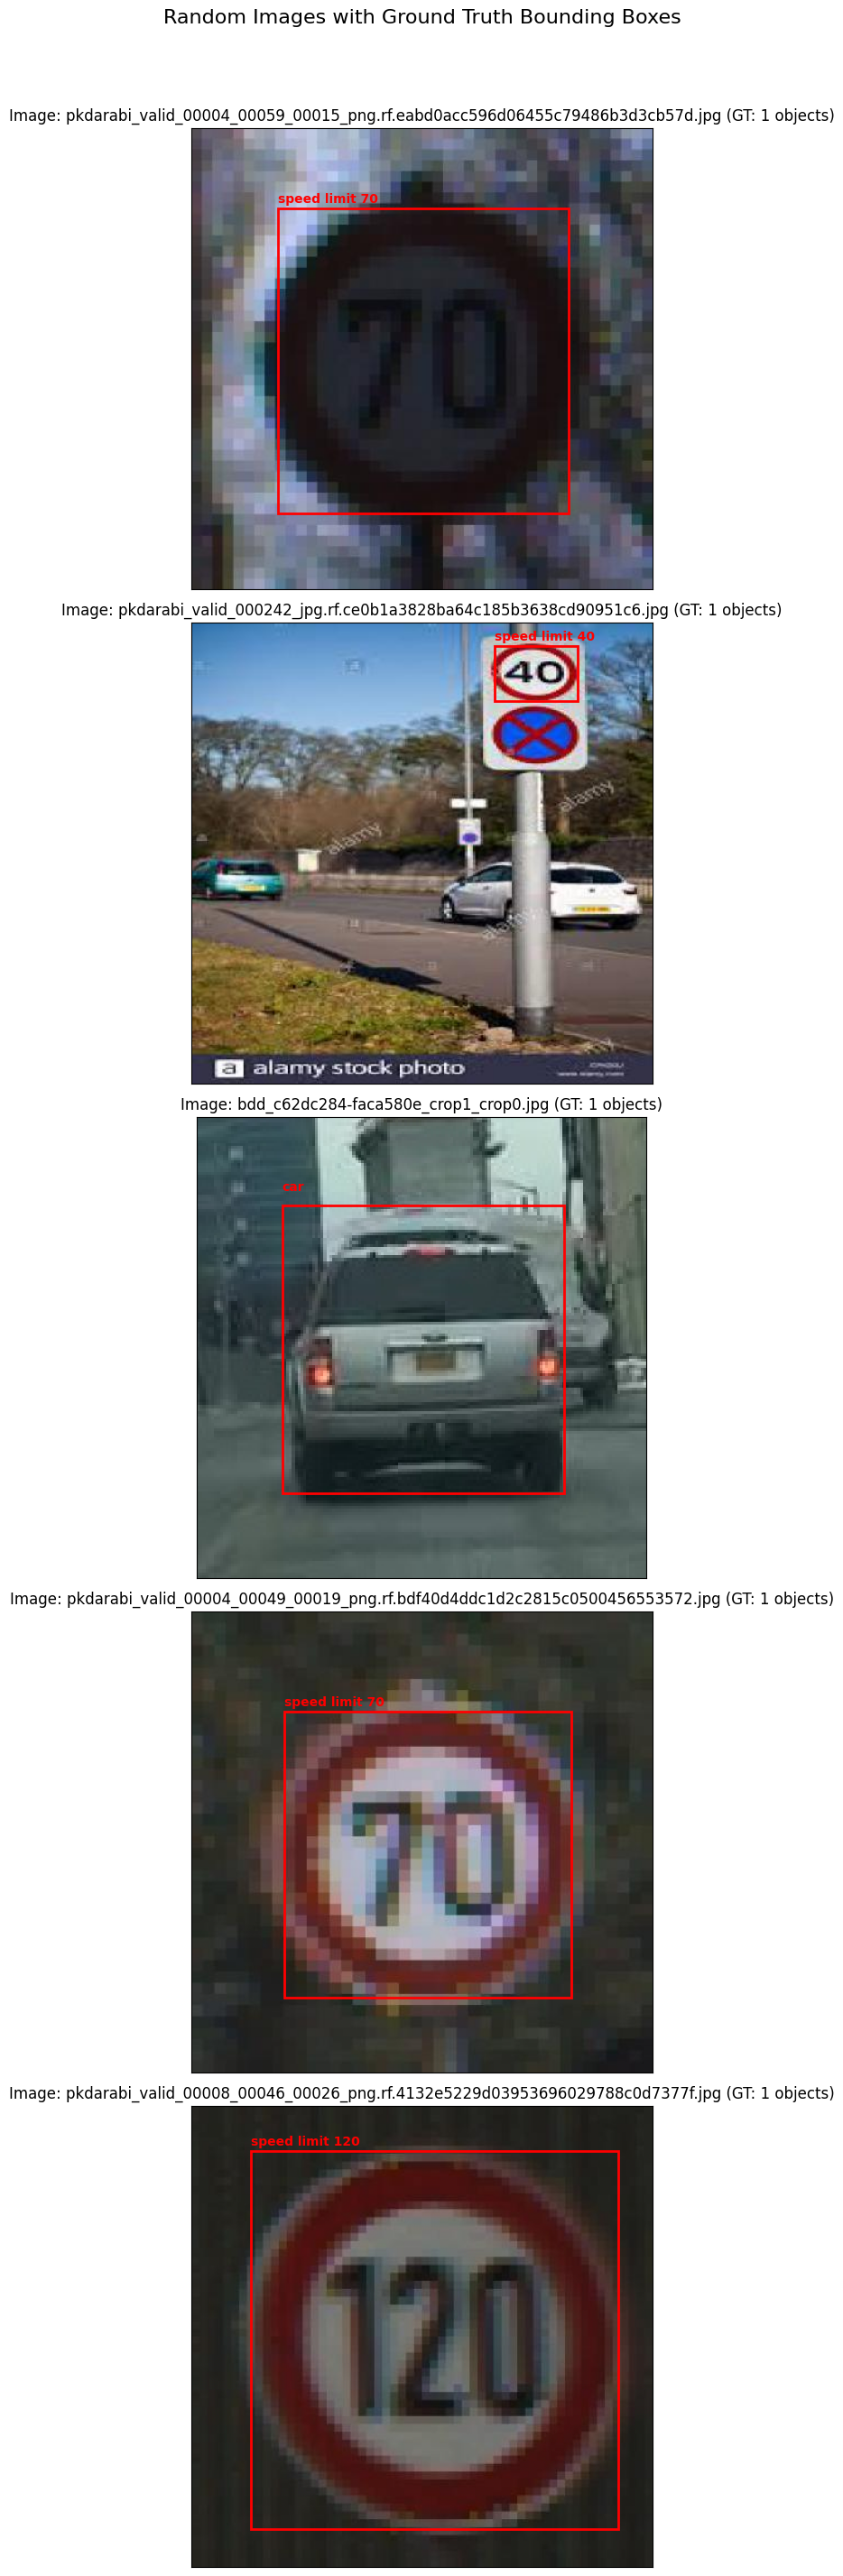

In [ ]:
def plot_boxes(ax, image, boxes, class_names):
    ax.imshow(image)
    ax.set_xticks([])
    ax.set_yticks([])

    # Iterate over bounding boxes and plot them
    for box_data in boxes:
        class_id, x_center_norm, y_center_norm, width_norm, height_norm = map(float, box_data[:5])
        class_name = class_names[int(class_id)]

        # Convert normalized coordinates to pixel coordinates
        img_width, img_height = image.size
        x_center, y_center = x_center_norm * img_width, y_center_norm * img_height
        box_width, box_height = width_norm * img_width, height_norm * img_height

        x_min = x_center - (box_width / 2)
        y_min = y_center - (box_height / 2)

        # Create a Rectangle patch
        rect = patches.Rectangle((x_min, y_min), box_width, box_height, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        ax.text(x_min, y_min - 5, class_name, color='r', fontsize=10, weight='bold')

# Get class names from data.yaml, assuming it's correctly formatted for YOLO
import yaml
with open(DATA_YAML, 'r') as f:
    data_info = yaml.safe_load(f)
    CLASS_NAMES = data_info['names']

# Select 5 random images from the validation set
NUM_IMAGES_TO_DISPLAY = 5
random_image_paths = random.sample(list(IMAGES_VAL.iterdir()), NUM_IMAGES_TO_DISPLAY)

fig, axes = plt.subplots(NUM_IMAGES_TO_DISPLAY, 1, figsize=(8, 6 * NUM_IMAGES_TO_DISPLAY))
fig.suptitle('Random Images with Ground Truth Bounding Boxes', fontsize=16)

for i, img_path in enumerate(random_image_paths):
    # Load the image
    image = Image.open(img_path).convert('RGB')

    # Load the corresponding label file
    label_path = Path(str(img_path).replace('images', 'labels')).with_suffix('.txt')
    gt_boxes = []
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                gt_boxes.append(list(map(float, line.strip().split())))

    plot_boxes(axes[i], image, gt_boxes, CLASS_NAMES)
    axes[i].set_title(f'Image: {img_path.name} (GT: {len(gt_boxes)} objects)')

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent suptitle overlap
plt.show()

In [ ]:
model = YOLO('yolov8n.pt')
print("YOLO model initialized successfully!")

YOLO model initialized successfully!


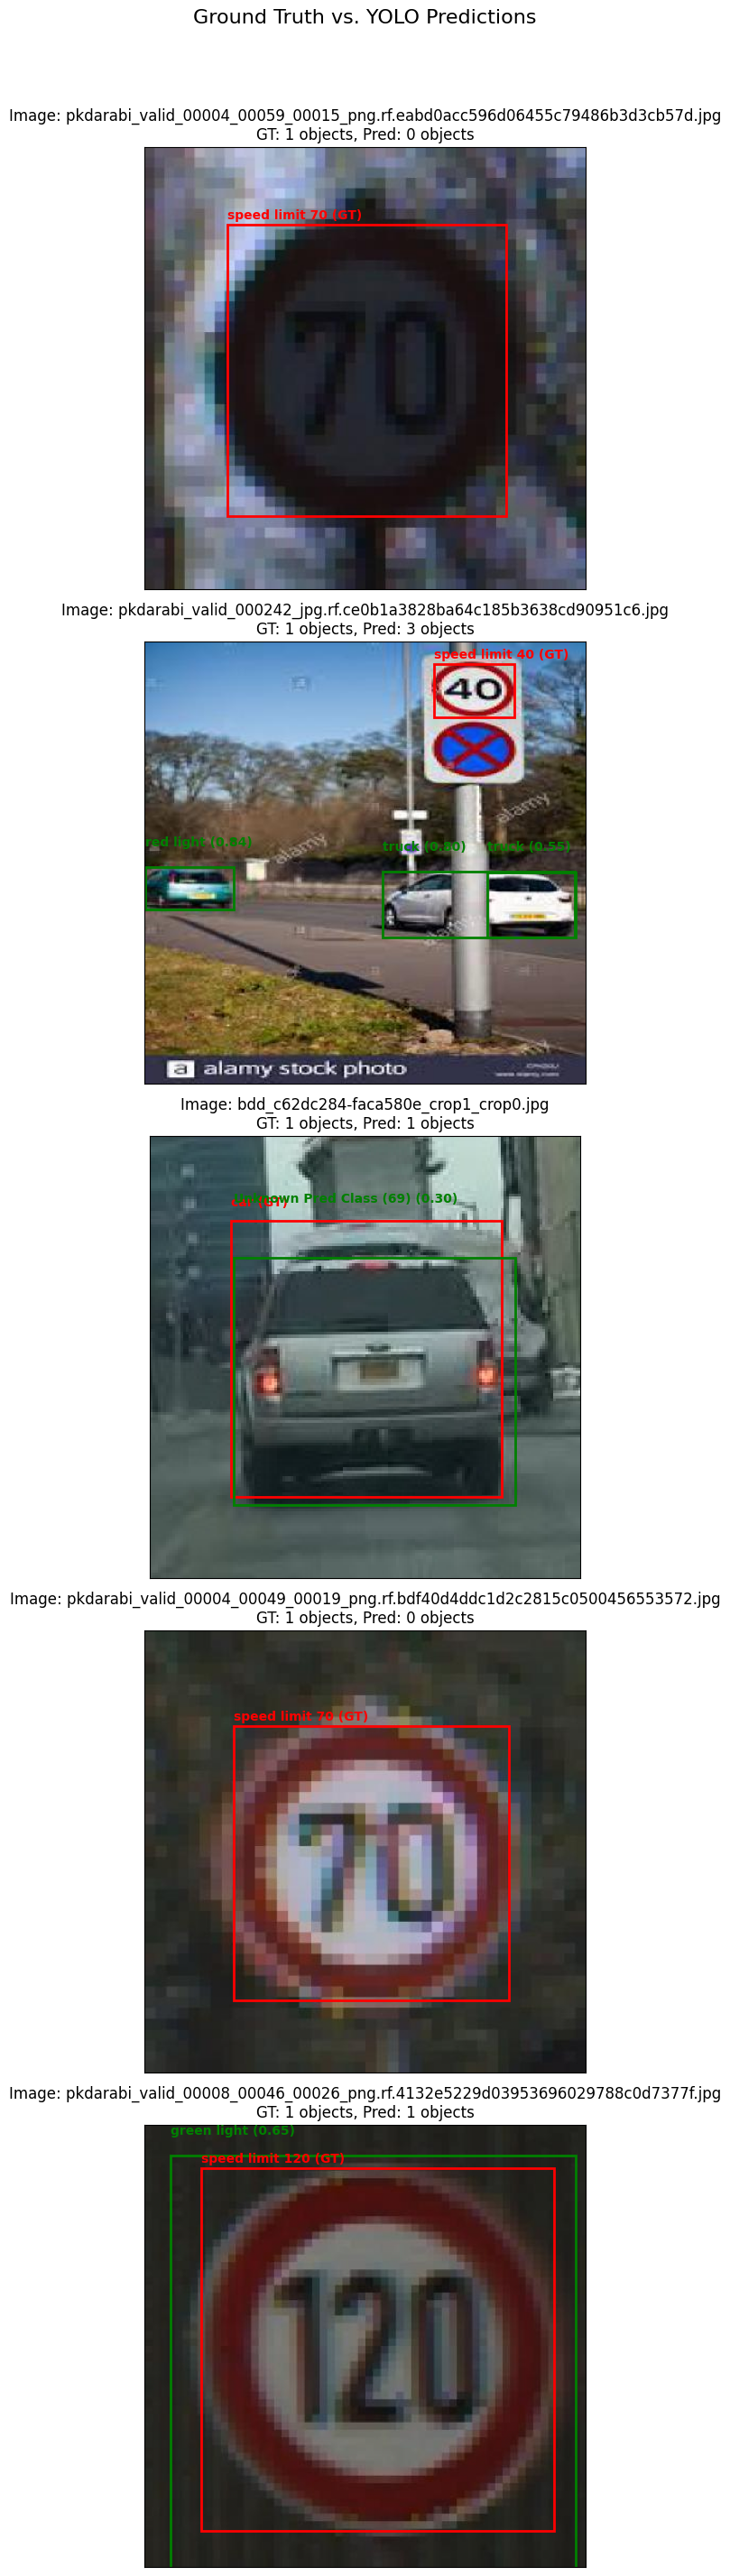

In [ ]:
def plot_predictions(ax, image, gt_boxes, pred_boxes, class_names):
    ax.imshow(image)
    ax.set_xticks([])
    ax.set_yticks([])

    # Plot Ground Truth Boxes (red)
    for box_data in gt_boxes:
        class_id, x_center_norm, y_center_norm, width_norm, height_norm = map(float, box_data[:5])
        try:
            class_name = class_names[int(class_id)]
        except KeyError:
            class_name = f"Unknown GT Class ({int(class_id)})"

        img_width, img_height = image.size
        x_center, y_center = x_center_norm * img_width, y_center_norm * img_height
        box_width, box_height = width_norm * img_width, height_norm * img_height

        x_min = x_center - (box_width / 2)
        y_min = y_center - (box_height / 2)

        rect = patches.Rectangle((x_min, y_min), box_width, box_height, linewidth=2, edgecolor='r', facecolor='none', label='Ground Truth')
        ax.add_patch(rect)
        ax.text(x_min, y_min - 5, class_name + ' (GT)', color='r', fontsize=10, weight='bold')

    # Plot Predicted Boxes (green)
    for box_data in pred_boxes:
        # YOLO prediction format: x_min, y_min, x_max, y_max, confidence, class_id
        x_min, y_min, x_max, y_max, confidence, class_id = box_data
        try:
            class_name = class_names[int(class_id)]
        except KeyError:
            class_name = f"Unknown Pred Class ({int(class_id)})"

        box_width = x_max - x_min
        box_height = y_max - y_min

        rect = patches.Rectangle((x_min, y_min), box_width, box_height, linewidth=2, edgecolor='g', facecolor='none', label='Prediction')
        ax.add_patch(rect)
        ax.text(x_min, y_min - 20, f'{class_name} ({confidence:.2f})', color='g', fontsize=10, weight='bold')

fig, axes = plt.subplots(NUM_IMAGES_TO_DISPLAY, 1, figsize=(8, 6 * NUM_IMAGES_TO_DISPLAY))
fig.suptitle('Ground Truth vs. YOLO Predictions', fontsize=16)

for i, img_path in enumerate(random_image_paths):
    # Load the image
    image = Image.open(img_path).convert('RGB')

    # Load the corresponding ground truth label file
    label_path = Path(str(img_path).replace('images', 'labels')).with_suffix('.txt')
    gt_boxes = []
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                gt_boxes.append(list(map(float, line.strip().split())))

    # Run inference with the YOLO model
    results = model(image, verbose=False) # verbose=False to suppress output for each image

    pred_boxes = []
    if results:
        for *xyxy, conf, cls in results[0].boxes.data.tolist():
            pred_boxes.append([*xyxy, conf, cls])

    plot_predictions(axes[i], image, gt_boxes, pred_boxes, CLASS_NAMES)
    axes[i].set_title(f'Image: {img_path.name}\nGT: {len(gt_boxes)} objects, Pred: {len(pred_boxes)} objects')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

### Train the YOLO Model

Silahkan dicoba training dan konfigurasi parameternya

In [ ]:
import yaml

# Load the data.yaml file
with open(DATA_YAML, 'r') as f:
    data_info = yaml.safe_load(f)

# Update the 'path' to the actual download location
data_info['path'] = str(path)

# Write the updated data.yaml back to the file
with open(DATA_YAML, 'w') as f:
    yaml.dump(data_info, f)

print(f"Updated data.yaml with correct path: {data_info['path']}")

model.train(data=DATA_YAML, epochs=50, imgsz=640)

Updated data.yaml with correct path: /root/.cache/kagglehub/datasets/guisahanes/traffic-violation-detection-dataset/versions/1
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/guisahanes/traffic-violation-detection-dataset/versions/1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=3

KeyboardInterrupt: 